In [2]:
# Primary imports
import os
import pickle
import sys
sys.path.append("..")

# Third party imports
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load results
exp_names = ['ACSPubcov_no_sex', 'ACSIncome_no_race']
exp_name = exp_names[0]
classifier = "tree"
results_dir = os.path.join("results", exp_name)
results_path = os.path.join(results_dir, classifier + '_mc_results.pkl')

with open(results_path, 'rb') as f:
    loaded_data = pickle.load(f)

In [4]:
# Initial eces
_initial_eces = [np.array(loaded_data[i]['initial eces']) for i in range(5)]
_initial_eces = np.stack(_initial_eces).T
initial_eces = np.mean(_initial_eces, axis=1)
initial_worst_ece = np.max(initial_eces)

# Final eces
_final_eces = [np.array(loaded_data[i]['final eces']) for i in range(5)]
_final_eces = np.stack(_final_eces).T
final_eces = np.mean(_final_eces, axis=1)
final_worst_ece = np.max(final_eces)

# Bounds
init_bound = np.mean(np.array([np.array(loaded_data[i]['init_bound']) for i in range(5)]))
final_bound = np.mean(np.array([np.array(loaded_data[i]['final_bound']) for i in range(5)]))

(0.002082994765291828, 0.2582746417387458)

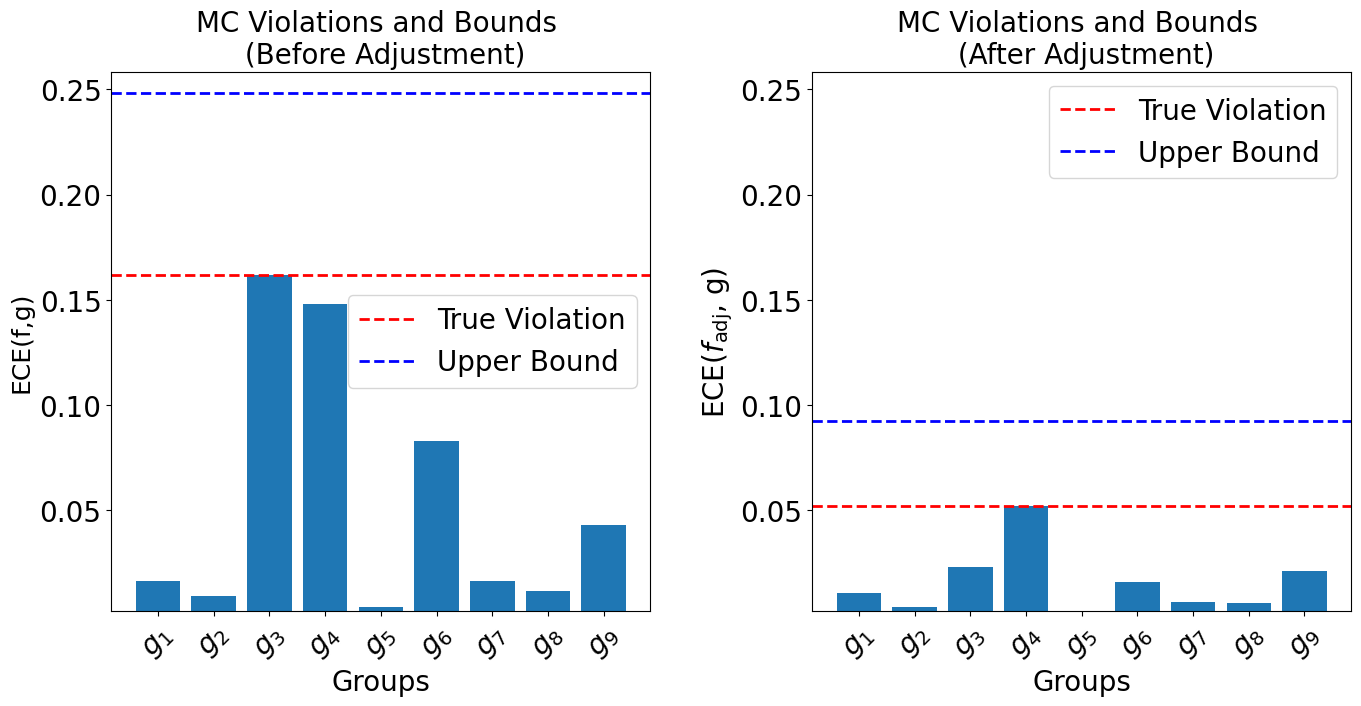

In [ ]:
font_size = 20
x_labels = [f"$g_{{{i}}}$" for i in range(1, initial_eces.shape[0] + 1)]  

# Create the subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'wspace': 0.3})

min_y = min(min(initial_eces), initial_worst_ece, init_bound, min(final_eces), final_worst_ece, final_bound)
max_y = max(max(initial_eces), initial_worst_ece, init_bound, max(final_eces), final_worst_ece, final_bound) + 0.01

# Plot the bar chart on the first subplot
axes[0].bar(x_labels, initial_eces)
axes[0].set_xlabel("Groups", fontsize=font_size)
axes[0].set_ylabel("ECE(f,g)", fontsize=18)
axes[0].set_title("MC Violations and Bounds \n (Before Adjustment)", fontsize=font_size)
axes[0].set_xticks(range(len(x_labels)))
axes[0].set_xticklabels(x_labels, rotation=45, fontsize=font_size)

# Set y-tick labels size
axes[0].tick_params(axis='y', labelsize=font_size)

# Add true violation and upper bound
axes[0].axhline(y=initial_worst_ece, color='red', linestyle='--', linewidth=2, label="True Violation")
axes[0].axhline(y=init_bound, color='blue', linestyle='--', linewidth=2, label="Upper Bound")
axes[0].legend(loc='best', fontsize=font_size)
axes[0].set_ylim(min_y, max_y)

# Plot the bar chart on the first subplot
axes[1].bar(x_labels, final_eces)
axes[1].set_xlabel("Groups", fontsize=font_size)
axes[1].set_ylabel(r"ECE($f_{\text{adj}}$, g)", fontsize=font_size)

axes[1].set_title("MC Violations and Bounds \n (After Adjustment)", fontsize=font_size)
axes[1].set_xticks(range(len(x_labels)))
axes[1].set_xticklabels(x_labels, rotation=45, fontsize=font_size)

# Set y-tick labels size
axes[1].tick_params(axis='y', labelsize=font_size)

# Add true violation and upper bound
axes[1].axhline(y=final_worst_ece, color='red', linestyle='--', linewidth=2, label="True Violation")
axes[1].axhline(y=final_bound, color='blue', linestyle='--', linewidth=2, label="Upper Bound")
axes[1].legend(loc='best', fontsize=font_size)
axes[1].set_ylim(min_y, max_y)

# plt.savefig(os.path.join(results_dir, exp_name + '_' + classifier + '_mc.pdf'), bbox_inches="tight")